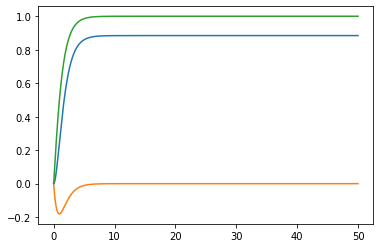

In [1]:
    import numpy as np
    from scipy.integrate import solve_bvp
    import matplotlib.pyplot as plt
    kappa=-1
    def oneDiskODE(z, y):
            # Y0 = H, Y1 = F', Y2 = F, Y3 = G', Y4 = G
            dydz = np.zeros((5, len(z)))
            dydz = np.array([-
                            2.0*
                            y[2], kappa * 
                            (y[2] *
                            y[2] +
                                y[0] *
                                y[1] -
                                (y[4] *
                                y[4]- 
                                1.0)) -
                            (2.0 -
                                kappa - 
                                kappa**2) *
                            (y[4] -
                                1.0), y[1], kappa *
                            (2.0 * 
                                y[2] *
                                y[4] +
                                y[0] *
                                y[3]) +
                            (2.0 -
                                kappa -
                                kappa**2) *
                            y[2], y[3]])
            return dydz 

    def oneDiskBC(ya, yb):
            resa = np.array([ya[0],
                            ya[2],
                            ya[4]])
            
            resb = np.array([yb[2],
                            yb[4] - 1.0])
            
            return np.concatenate((resa, resb))


    z = np.linspace(0, 50, 20000)
    y = np.zeros((5, len(z)))
    y_guess = np.zeros((5, z.size))
    if kappa == 1:
            y_guess[0] = 1.2
            y_guess[1] = 0
            y_guess[2] = 0
            y_guess[3] = 0
            y_guess[4] = 1
    elif kappa == -1:
            y_guess[0] = 1.2
            y_guess[1] = 0
            y_guess[2] = 0
            y_guess[3] = 0
            y_guess[4] = 1
    else:
            y_guess[0] = 1.2
            y_guess[1] = 0
            y_guess[2] = 0
            y_guess[3] = 0
            y_guess[4] = 1




    solution = solve_bvp(oneDiskODE, oneDiskBC, z, y_guess,tol=1e-10,max_nodes=5000000)

    x_plot = np.linspace(0, 50, 20000)


    y1_plot = solution.sol(x_plot)[0]
    y2_plot = solution.sol(x_plot)[2]
    y3_plot = solution.sol(x_plot)[4]
    y4_plot = solution.sol(x_plot)[1]
    y5_plot = solution.sol(x_plot)[3]



    plt.plot(x_plot, y1_plot, x_plot, y2_plot, x_plot, y3_plot)
        #plt.plot(x_plot, y1_plot)
    plt.show()

    data = np.column_stack((x_plot, y1_plot, y2_plot, y3_plot,y4_plot,y5_plot))

        # 保存到文件中
    # np.savetxt("1.txt", data)
